# Markdown Pricing Simulator & RL-Based Optimal Discount Policy
## Exhaustive Data Exploration — Brazilian E-Commerce Dataset

This notebook performs comprehensive data exploration of the Brazilian E-Commerce dataset (Olist) to understand:
- Order and revenue patterns
- Product/category distributions  
- Price elasticity signals
- Temporal demand patterns
- Customer behavior & willingness-to-pay

These insights will drive the design of a realistic markdown pricing simulator.

In [1]:
# ============================================================
# Section 1: Environment Setup & Imports
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '/Users/ajit/Documents/Pricing/'
print("All imports successful")
print(f"Data directory: {DATA_DIR}")

All imports successful
Data directory: /Users/ajit/Documents/Pricing/


## Section 2: Data Acquisition & Loading

Load all CSV files from the Brazilian E-Commerce dataset and merge into a unified master dataframe.

In [2]:
# Load all datasets
orders = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
customers = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
payments = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
sellers = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
geolocation = pd.read_csv(DATA_DIR + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

datasets = {
    'orders': orders, 'order_items': order_items, 'products': products,
    'customers': customers, 'payments': payments, 'reviews': reviews,
    'sellers': sellers, 'geolocation': geolocation, 'category_translation': category_translation
}

print("Dataset Shapes:")
print("=" * 50)
for name, df in datasets.items():
    print(f"{name:25s}: {str(df.shape):>15s}")

# Convert date columns
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']
for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
print("\nDate columns converted successfully")

Dataset Shapes:
orders                   :      (99441, 8)
order_items              :     (112650, 7)
products                 :      (32951, 9)
customers                :      (99441, 5)
payments                 :     (103886, 5)
reviews                  :      (99224, 7)
sellers                  :       (3095, 4)
geolocation              :    (1000163, 5)
category_translation     :         (71, 2)

Date columns converted successfully


In [3]:
# Create master dataframe by merging all tables
# Translate product categories to English
products_en = products.merge(category_translation, on='product_category_name', how='left')
products_en['product_category_name_english'] = products_en['product_category_name_english'].fillna(products_en['product_category_name'])

# Build master: order_items -> orders -> products -> customers -> payments -> reviews
master = order_items.merge(orders, on='order_id', how='left')
master = master.merge(products_en, on='product_id', how='left')
master = master.merge(customers, on='customer_id', how='left')

# Aggregate payments per order (since multiple payment types possible)
payment_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    num_installments=('payment_installments', 'max'),
    payment_type=('payment_type', 'first')
).reset_index()
master = master.merge(payment_agg, on='order_id', how='left')

# Merge review scores (average per order)
review_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()
master = master.merge(review_agg, on='order_id', how='left')

print(f"Master dataframe shape: {master.shape}")
print(f"\nColumns: {list(master.columns)}")
print(f"\nDate range: {master['order_purchase_timestamp'].min()} to {master['order_purchase_timestamp'].max()}")
print(f"\nMissing values (top 10):")
print(master.isnull().sum().sort_values(ascending=False).head(10))

Master dataframe shape: (112650, 31)

Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_payment', 'num_installments', 'payment_type', 'review_score']

Date range: 2016-09-04 21:15:19 to 2018-09-03 09:06:57

Missing values (top 10):
order_delivered_customer_date    2454
product_name_lenght              1603
product_category_name_english    1603
product_photos_qty               1603
product_description_lenght       1603
product_category_name       

## Section 3: Orders & Revenue Analysis

Analyze temporal patterns in orders and revenue, payment behavior, and revenue concentration.

In [4]:
# Filter to delivered orders only for cleaner analysis
delivered = master[master['order_status'] == 'delivered'].copy()
delivered['order_date'] = delivered['order_purchase_timestamp'].dt.date
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')
delivered['order_week'] = delivered['order_purchase_timestamp'].dt.to_period('W')
delivered['total_item_value'] = delivered['price'] + delivered['freight_value']

print(f"Delivered orders: {delivered['order_id'].nunique():,}")
print(f"Total items: {len(delivered):,}")
print(f"Total revenue (item price): ${delivered['price'].sum():,.2f}")
print(f"Average order value: ${delivered.groupby('order_id')['price'].sum().mean():,.2f}")
print(f"Median item price: ${delivered['price'].median():,.2f}")

# Summary statistics
print("\n--- Price Statistics ---")
print(delivered['price'].describe())
print(f"\n--- Freight Statistics ---")
print(delivered['freight_value'].describe())

Delivered orders: 96,478
Total items: 110,197
Total revenue (item price): $13,221,498.11
Average order value: $137.04
Median item price: $74.90

--- Price Statistics ---
count    110197.000000
mean        119.980563
std         182.299446
min           0.850000
25%          39.900000
50%          74.900000
75%         134.170000
max        6735.000000
Name: price, dtype: float64

--- Freight Statistics ---
count    110197.000000
mean         19.948598
std          15.698136
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64


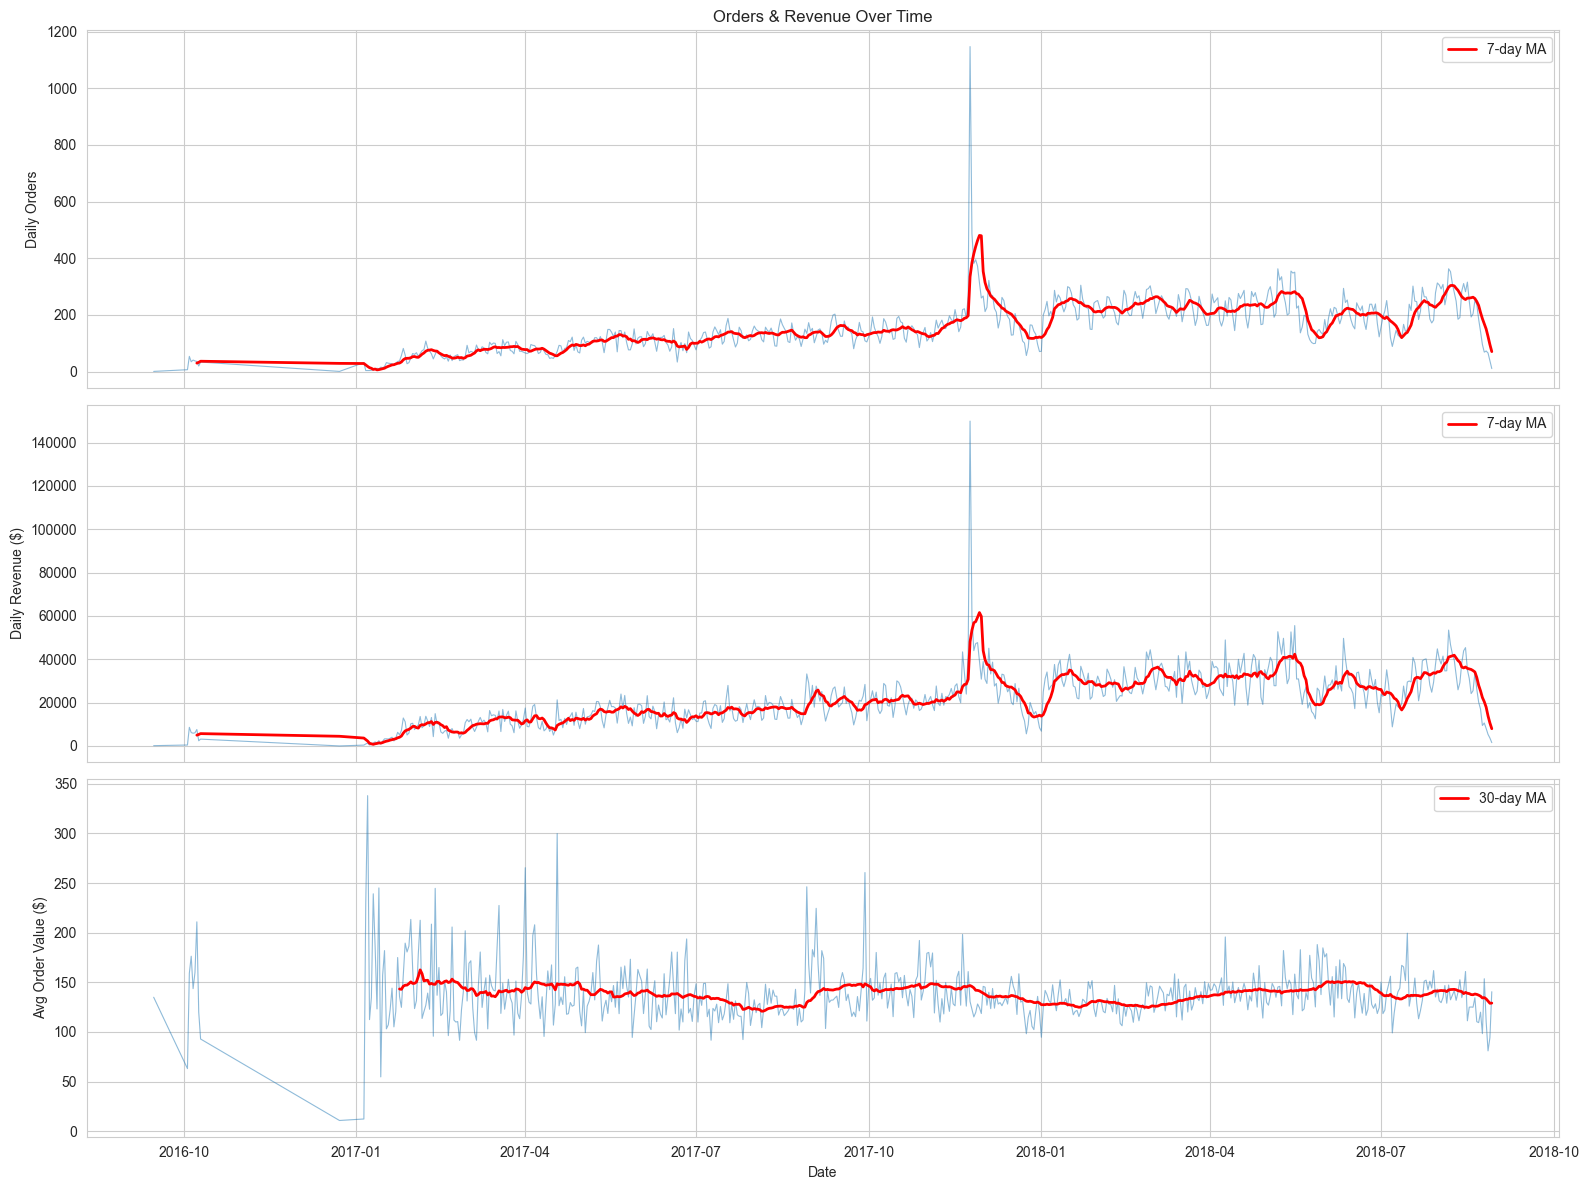

In [5]:
# Time series of orders and revenue
daily_orders = delivered.groupby('order_date').agg(
    num_orders=('order_id', 'nunique'),
    num_items=('order_id', 'count'),
    revenue=('price', 'sum')
).reset_index()
daily_orders['order_date'] = pd.to_datetime(daily_orders['order_date'])

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Daily orders
axes[0].plot(daily_orders['order_date'], daily_orders['num_orders'], alpha=0.5, linewidth=0.8)
axes[0].plot(daily_orders['order_date'], daily_orders['num_orders'].rolling(7).mean(), 'r-', linewidth=2, label='7-day MA')
axes[0].set_ylabel('Daily Orders')
axes[0].set_title('Orders & Revenue Over Time')
axes[0].legend()

# Daily revenue
axes[1].plot(daily_orders['order_date'], daily_orders['revenue'], alpha=0.5, linewidth=0.8)
axes[1].plot(daily_orders['order_date'], daily_orders['revenue'].rolling(7).mean(), 'r-', linewidth=2, label='7-day MA')
axes[1].set_ylabel('Daily Revenue ($)')
axes[1].legend()

# Avg order value
axes[2].plot(daily_orders['order_date'], daily_orders['revenue'] / daily_orders['num_orders'], alpha=0.5, linewidth=0.8)
ma = (daily_orders['revenue'] / daily_orders['num_orders']).rolling(30).mean()
axes[2].plot(daily_orders['order_date'], ma, 'r-', linewidth=2, label='30-day MA')
axes[2].set_ylabel('Avg Order Value ($)')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_orders_revenue_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

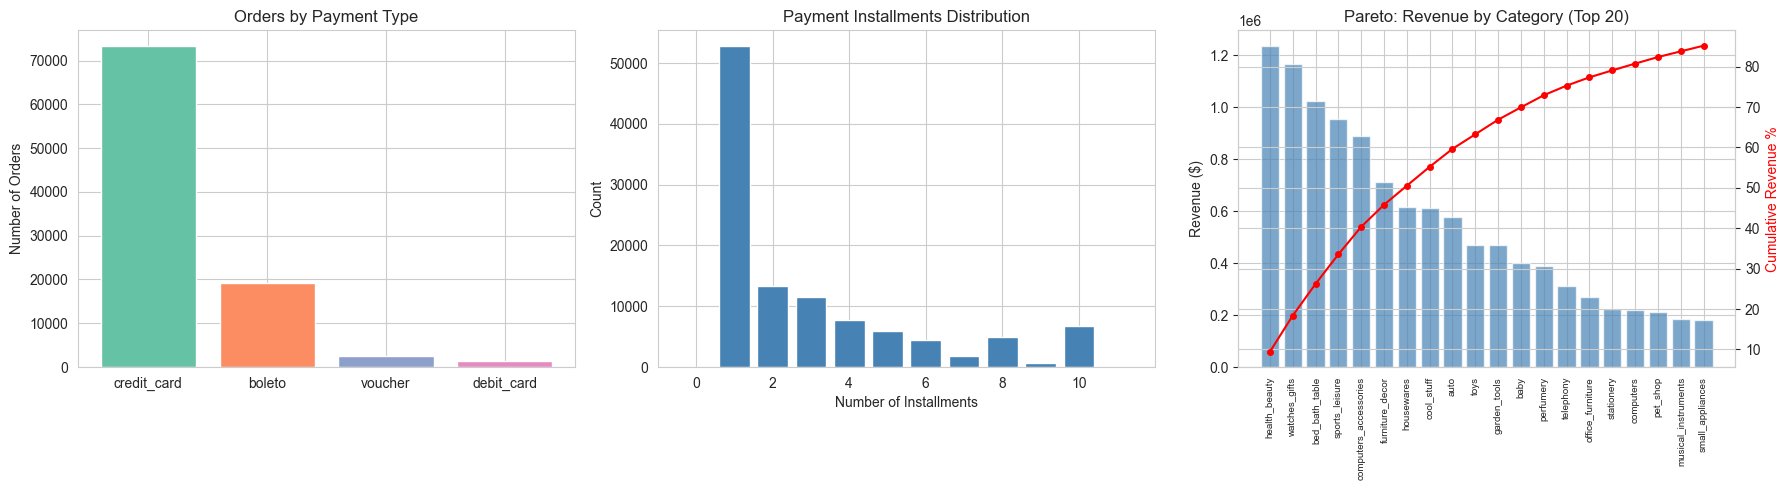


Top 20 categories account for 85.2% of revenue
Top 5 categories: ['health_beauty', 'watches_gifts', 'bed_bath_table', 'sports_leisure', 'computers_accessories']


In [6]:
# Payment analysis and Pareto chart of revenue by category
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Payment type distribution
pay_dist = delivered.groupby('payment_type')['order_id'].nunique().sort_values(ascending=False)
axes[0].bar(pay_dist.index, pay_dist.values, color=sns.color_palette('Set2'))
axes[0].set_title('Orders by Payment Type')
axes[0].set_ylabel('Number of Orders')

# Installment distribution
inst_dist = delivered['num_installments'].value_counts().sort_index().head(12)
axes[1].bar(inst_dist.index, inst_dist.values, color='steelblue')
axes[1].set_title('Payment Installments Distribution')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Count')

# Pareto chart: revenue by category (top 20)
cat_revenue = delivered.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)
top20 = cat_revenue.head(20)
cumulative_pct = top20.cumsum() / cat_revenue.sum() * 100
ax3 = axes[2]
ax3.bar(range(len(top20)), top20.values, color='steelblue', alpha=0.7)
ax3_twin = ax3.twinx()
ax3_twin.plot(range(len(top20)), cumulative_pct.values, 'r-o', markersize=4)
ax3_twin.set_ylabel('Cumulative Revenue %', color='red')
ax3.set_xticks(range(len(top20)))
ax3.set_xticklabels(top20.index, rotation=90, fontsize=7)
ax3.set_title('Pareto: Revenue by Category (Top 20)')
ax3.set_ylabel('Revenue ($)')

plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_payment_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 20 categories account for {cumulative_pct.iloc[-1]:.1f}% of revenue")
print(f"Top 5 categories: {list(top20.index[:5])}")

## Section 4: Product & Category Analysis

Examine product diversity, category distributions, and identify natural segments for the simulator.

In [7]:
# Product and category statistics
print(f"Unique products: {delivered['product_id'].nunique():,}")
print(f"Unique categories: {delivered['product_category_name_english'].nunique()}")
print(f"Unique sellers: {delivered['seller_id'].nunique():,}")

# Products per category
cat_stats = delivered.groupby('product_category_name_english').agg(
    num_products=('product_id', 'nunique'),
    num_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    price_std=('price', 'std'),
    avg_review=('review_score', 'mean'),
    num_sellers=('seller_id', 'nunique')
).sort_values('total_revenue', ascending=False)

cat_stats['price_cv'] = cat_stats['price_std'] / cat_stats['avg_price']  # Coefficient of variation
cat_stats['revenue_per_product'] = cat_stats['total_revenue'] / cat_stats['num_products']
cat_stats['orders_per_product'] = cat_stats['num_orders'] / cat_stats['num_products']

print(f"\n--- Top 15 Categories by Revenue ---")
print(cat_stats[['num_products', 'num_orders', 'total_revenue', 'avg_price', 'price_cv', 'avg_review']].head(15).to_string())

# Products with multiple sellers (price competition signal)
product_seller_counts = delivered.groupby('product_id')['seller_id'].nunique()
multi_seller = product_seller_counts[product_seller_counts > 1]
print(f"\n\nProducts with multiple sellers: {len(multi_seller):,} ({len(multi_seller)/delivered['product_id'].nunique()*100:.1f}%)")
print(f"Max sellers for one product: {multi_seller.max()}")

# Price variation within products (cross-seller price variation)
product_price_var = delivered.groupby('product_id')['price'].agg(['mean', 'std', 'min', 'max', 'count'])
product_price_var['price_range'] = product_price_var['max'] - product_price_var['min']
product_price_var['price_range_pct'] = product_price_var['price_range'] / product_price_var['mean'] * 100
has_variation = product_price_var[(product_price_var['count'] > 5) & (product_price_var['price_range_pct'] > 5)]
print(f"\nProducts with >5 orders AND >5% price range: {len(has_variation):,}")
print(f"Average price range for these products: {has_variation['price_range_pct'].mean():.1f}%")

Unique products: 32,216
Unique categories: 73
Unique sellers: 2,970

--- Top 15 Categories by Revenue ---
                               num_products  num_orders  total_revenue   avg_price  price_cv  avg_review
product_category_name_english                                                                           
health_beauty                          2397        8647     1233131.72  130.283330  1.379982    4.189729
watches_gifts                          1300        5495     1166176.98  199.040276  1.275111    4.071711
bed_bath_table                         2991        9272     1023434.76   93.438762  0.882427    3.923968
sports_leisure                         2822        7530      954852.55  113.254958  1.409948    4.165493
computers_accessories                  1600        6530      888724.61  116.264339  1.464674    3.986462
furniture_decor                        2593        6307      711927.69   87.246040  1.014017    3.953775
housewares                             2282        574

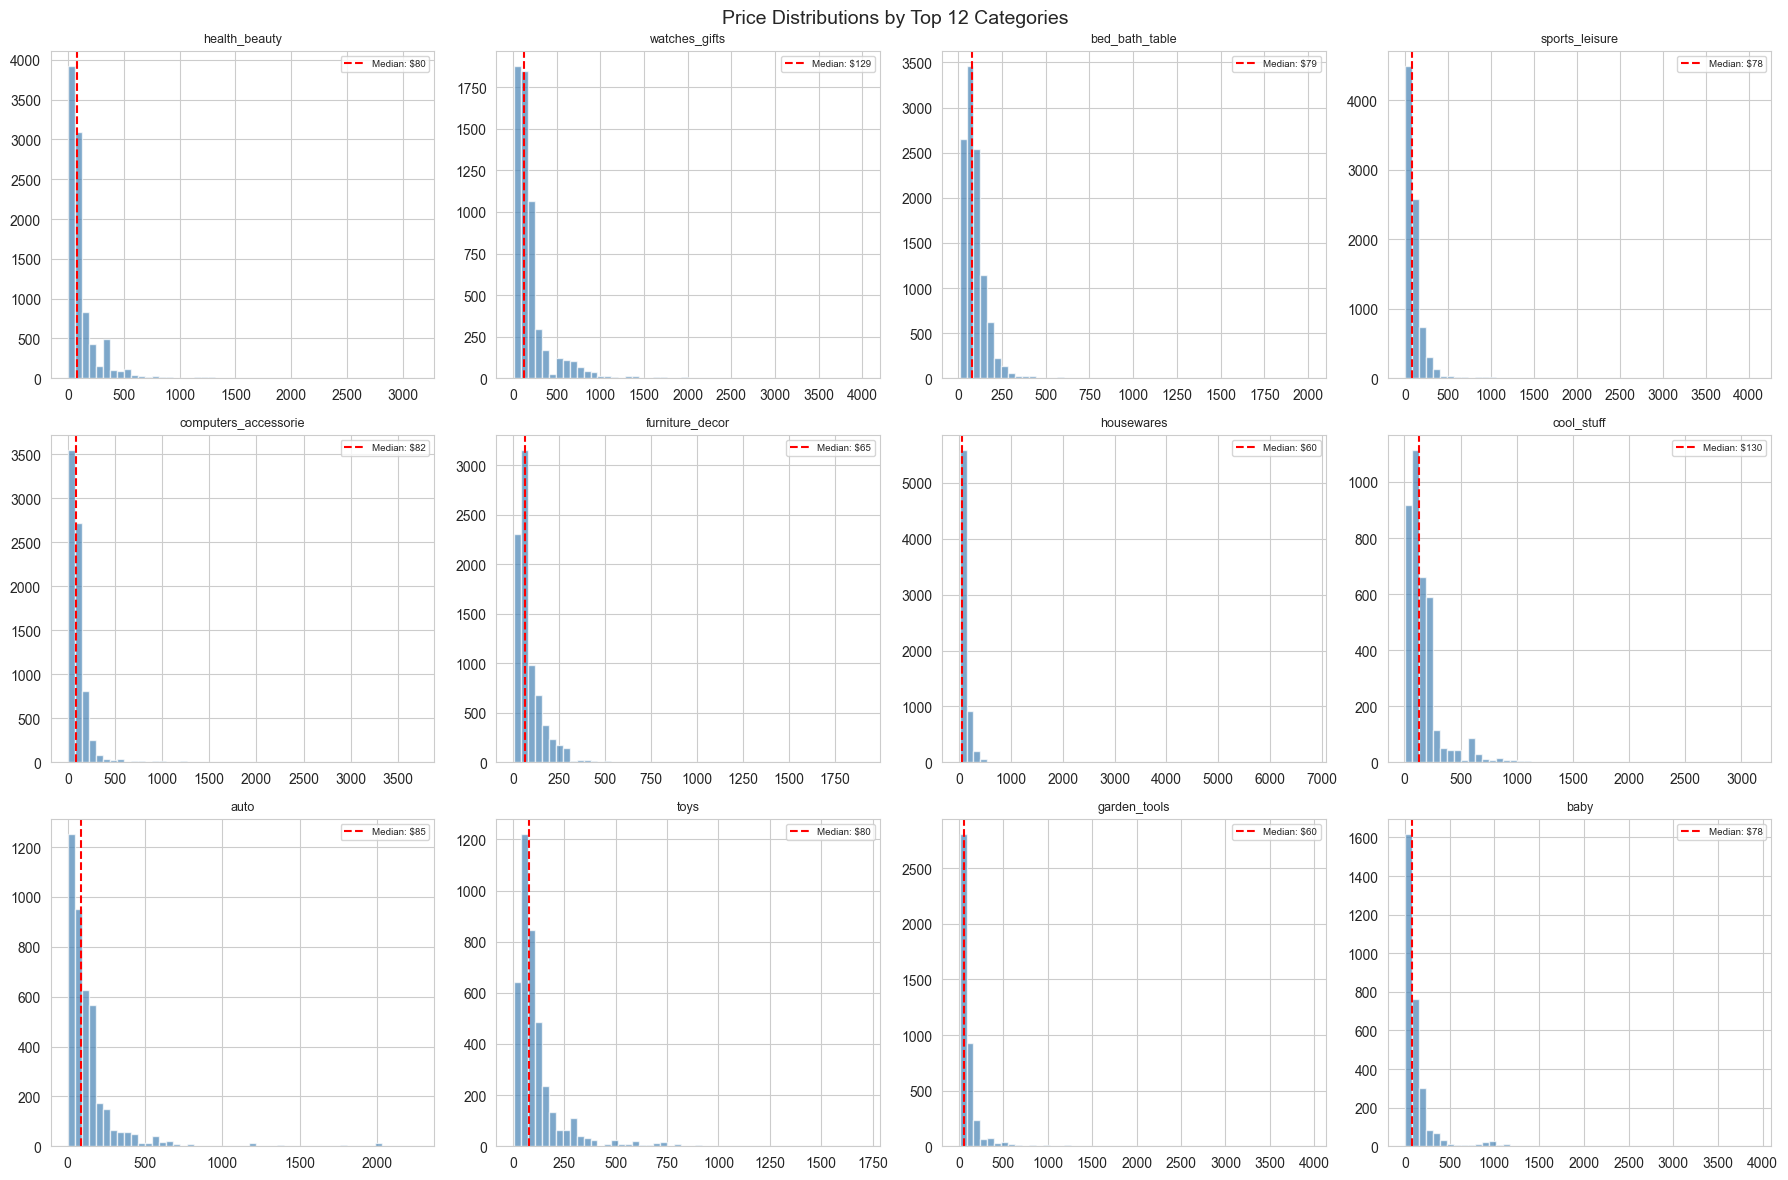

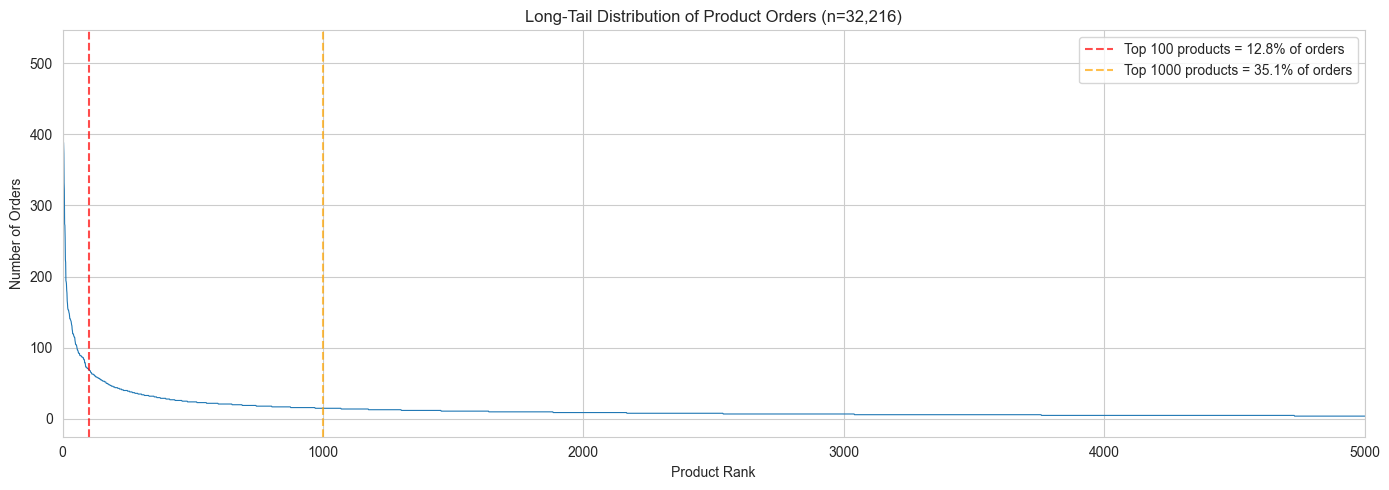

In [8]:
# Category price distributions (top 12 by revenue)
top12_cats = cat_stats.head(12).index.tolist()
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for i, cat in enumerate(top12_cats):
    ax = axes[i // 4, i % 4]
    cat_data = delivered[delivered['product_category_name_english'] == cat]['price']
    ax.hist(cat_data, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(cat_data.median(), color='red', linestyle='--', label=f'Median: ${cat_data.median():.0f}')
    ax.set_title(cat[:20], fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle('Price Distributions by Top 12 Categories', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_price_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Long-tail analysis: orders per product
product_orders = delivered.groupby('product_id').size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(product_orders)), product_orders.values, linewidth=0.8)
ax.set_xlabel('Product Rank')
ax.set_ylabel('Number of Orders')
ax.set_title(f'Long-Tail Distribution of Product Orders (n={len(product_orders):,})')
ax.axvline(x=100, color='red', linestyle='--', alpha=0.7, label=f'Top 100 products = {product_orders.head(100).sum()/len(delivered)*100:.1f}% of orders')
ax.axvline(x=1000, color='orange', linestyle='--', alpha=0.7, label=f'Top 1000 products = {product_orders.head(1000).sum()/len(delivered)*100:.1f}% of orders')
ax.legend()
ax.set_xlim(0, 5000)
plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_longtail.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Price Elasticity Signals

Analyze price variation within categories and across sellers to extract implicit elasticity signals.

Products with multiple sellers with price variation:
         min_price    max_price  num_sellers  total_sales   spread_pct
count  1149.000000  1149.000000  1149.000000  1149.000000  1149.000000
mean    139.220262   160.891473     2.218451    11.872933    18.449744
std     173.303766   198.257260     0.620616    25.109333    33.459868
min       5.000000     6.490000     2.000000     2.000000     0.001429
25%      49.000000    56.100000     2.000000     3.000000     3.449465
50%      91.000000   100.020833     2.000000     5.000000    10.344828
75%     159.000000   186.900000     2.000000    11.000000    22.913505
max    2221.000000  2350.000000     8.000000   477.000000   688.151659


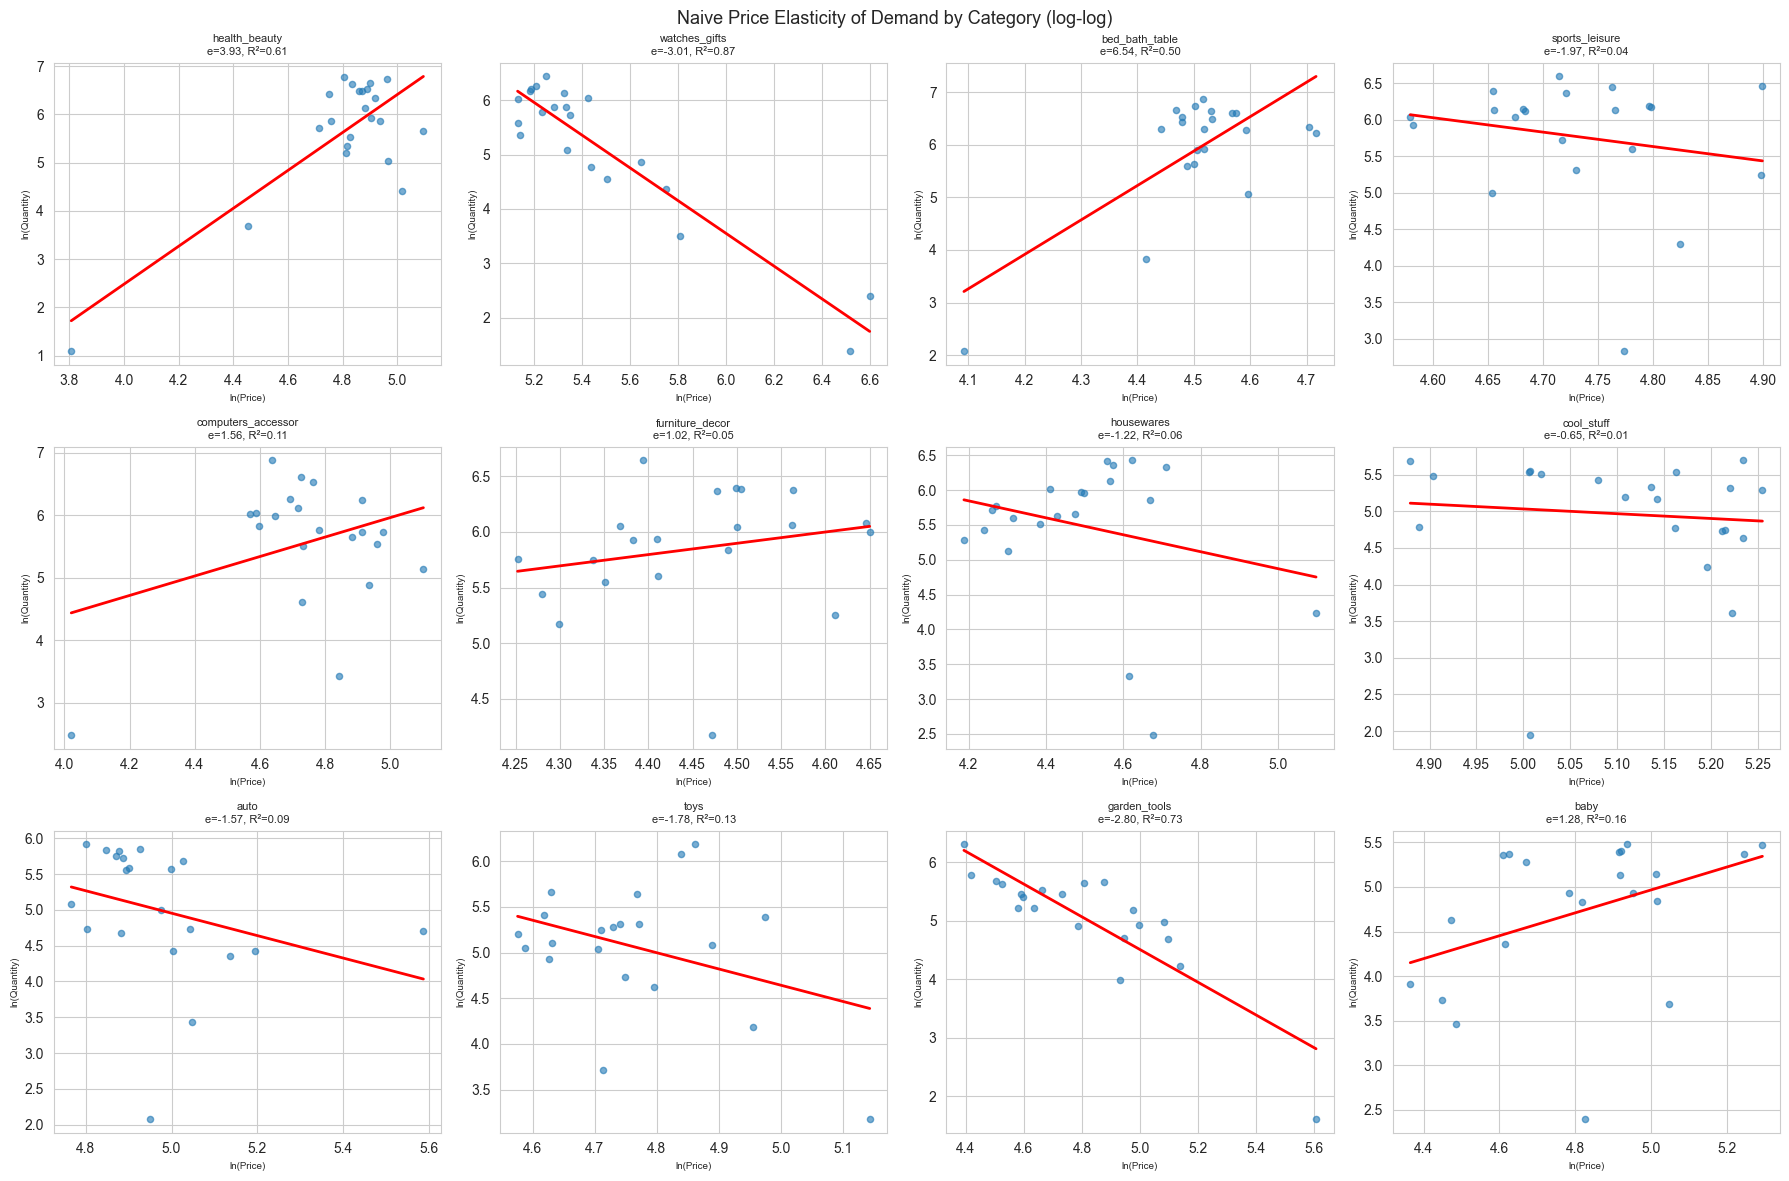


Estimated Naive Elasticities:
                       elasticity        r2       p_value
watches_gifts           -3.012480  0.871038  6.811056e-10
garden_tools            -2.799816  0.730495  8.092506e-07
sports_leisure          -1.972927  0.038681  3.928417e-01
toys                    -1.782037  0.130839  1.071370e-01
auto                    -1.568875  0.087095  1.940301e-01
housewares              -1.217038  0.064627  2.661241e-01
cool_stuff              -0.651851  0.008417  6.924530e-01
furniture_decor          1.015263  0.047162  3.443529e-01
baby                     1.283180  0.156253  7.613452e-02
computers_accessories    1.557744  0.110482  1.409772e-01
health_beauty            3.929839  0.613726  1.619051e-05
bed_bath_table           6.540947  0.501695  3.266875e-04


In [9]:
# Cross-seller price variation: same product, different prices = natural experiment
# Find products sold by multiple sellers at different prices
product_seller_prices = delivered.groupby(['product_id', 'seller_id']).agg(
    avg_price=('price', 'mean'),
    num_sales=('order_id', 'count')
).reset_index()

# Products with >1 seller
multi = product_seller_prices.groupby('product_id').filter(lambda x: len(x) > 1)
price_spread = multi.groupby('product_id').agg(
    min_price=('avg_price', 'min'),
    max_price=('avg_price', 'max'),
    num_sellers=('seller_id', 'count'),
    total_sales=('num_sales', 'sum')
)
price_spread['spread_pct'] = (price_spread['max_price'] - price_spread['min_price']) / price_spread['min_price'] * 100

print(f"Products with multiple sellers with price variation:")
print(price_spread[price_spread['spread_pct'] > 0].describe())

# Category-level price-quantity analysis (naive elasticity)
# Group by category and monthly price bin to get price-quantity pairs
delivered['month'] = delivered['order_purchase_timestamp'].dt.to_period('M')
cat_month_data = delivered.groupby(['product_category_name_english', 'month']).agg(
    avg_price=('price', 'mean'),
    quantity=('order_id', 'count'),
    median_price=('price', 'median')
).reset_index()

# For each category, compute naive elasticity as correlation between log(price) and log(quantity)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
elasticity_results = {}
for i, cat in enumerate(top12_cats):
    ax = axes[i // 4, i % 4]
    cat_data = cat_month_data[cat_month_data['product_category_name_english'] == cat].copy()
    cat_data = cat_data[cat_data['quantity'] > 0]
    if len(cat_data) > 5:
        log_p = np.log(cat_data['avg_price'])
        log_q = np.log(cat_data['quantity'])
        slope, intercept, r_value, p_value, std_err = stats.linregress(log_p, log_q)
        elasticity_results[cat] = {'elasticity': slope, 'r2': r_value**2, 'p_value': p_value}
        ax.scatter(log_p, log_q, alpha=0.6, s=20)
        x_pred = np.linspace(log_p.min(), log_p.max(), 50)
        ax.plot(x_pred, intercept + slope * x_pred, 'r-', linewidth=2)
        ax.set_title(f'{cat[:18]}\ne={slope:.2f}, R²={r_value**2:.2f}', fontsize=8)
    ax.set_xlabel('ln(Price)', fontsize=7)
    ax.set_ylabel('ln(Quantity)', fontsize=7)

plt.suptitle('Naive Price Elasticity of Demand by Category (log-log)', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_elasticity_signals.png', dpi=150, bbox_inches='tight')
plt.show()

elast_df = pd.DataFrame(elasticity_results).T.sort_values('elasticity')
print("\nEstimated Naive Elasticities:")
print(elast_df.to_string())

## Section 6: Temporal Patterns & Seasonality

Analyze day-of-week, hour-of-day effects, seasonality, and promotional demand spikes.

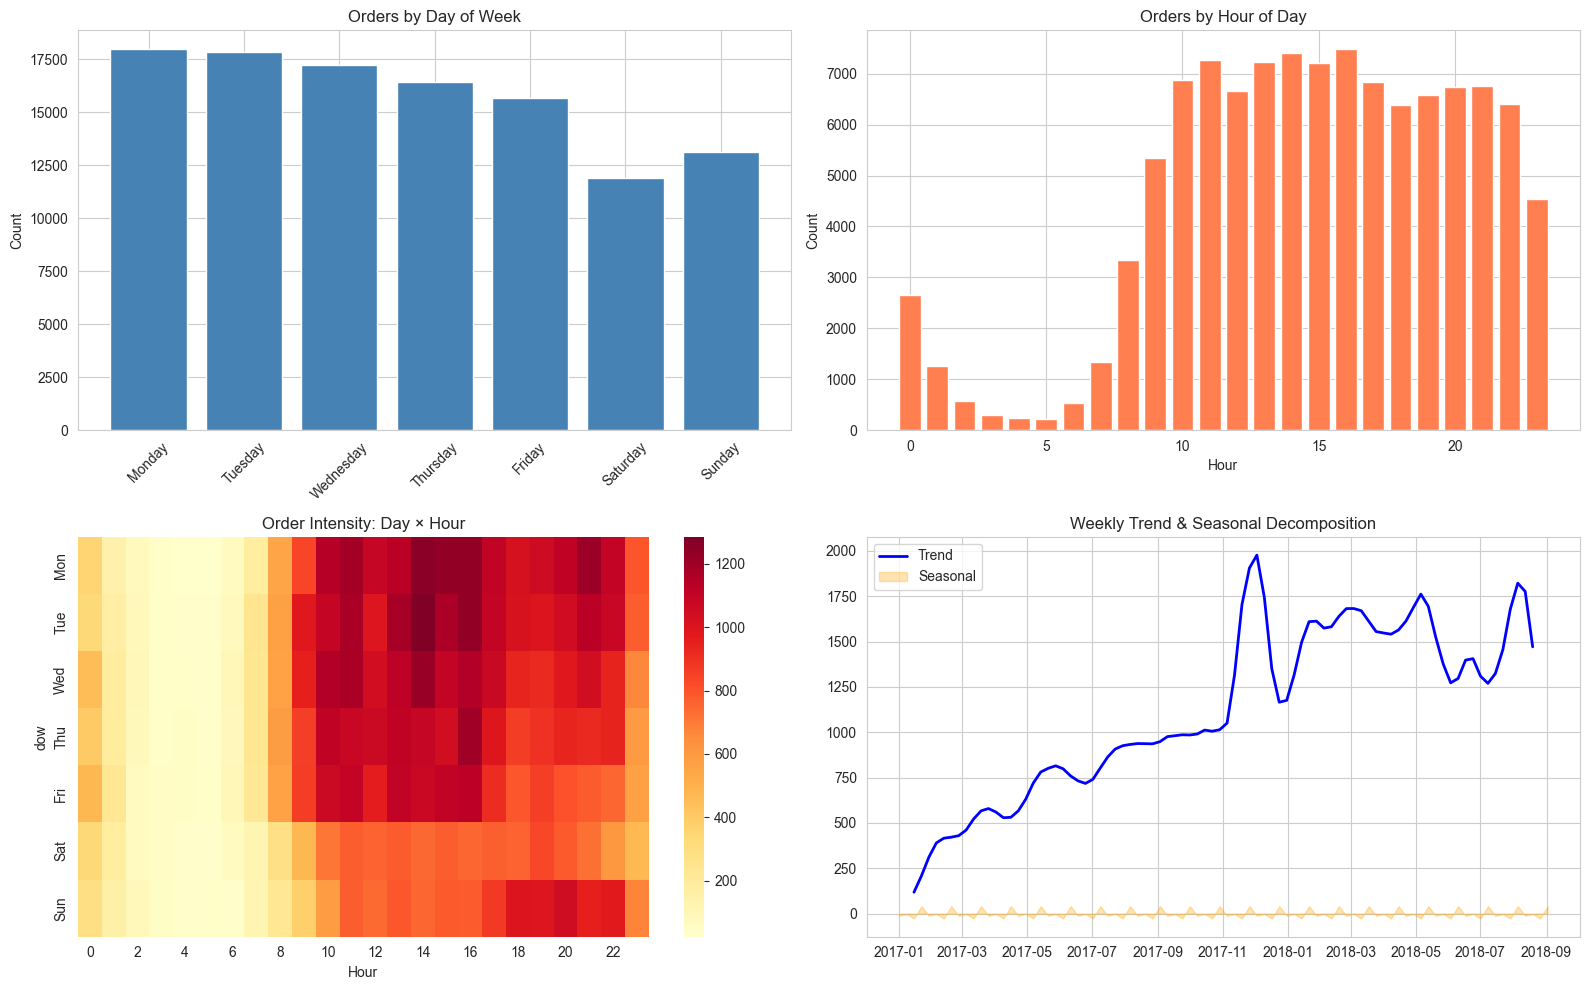


Peak order days (potential promotions):
order_date  num_orders   revenue
2017-11-24        1147 149916.58
2017-11-25         487  59928.51
2017-11-27         395  47237.27
2017-11-26         382  44000.48
2017-11-28         372  47694.76
2018-05-07         363  52726.03
2018-08-06         363  53475.41
2018-05-14         355  52633.10
2018-08-07         353  46744.20
2018-05-16         351  55562.13


In [10]:
# Temporal decomposition and patterns
delivered['dow'] = delivered['order_purchase_timestamp'].dt.dayofweek
delivered['hour'] = delivered['order_purchase_timestamp'].dt.hour
delivered['day_name'] = delivered['order_purchase_timestamp'].dt.day_name()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = delivered.groupby('day_name').size().reindex(dow_order)
axes[0, 0].bar(dow_order, dow_counts.values, color='steelblue')
axes[0, 0].set_title('Orders by Day of Week')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Hour of day
hour_counts = delivered.groupby('hour').size()
axes[0, 1].bar(hour_counts.index, hour_counts.values, color='coral')
axes[0, 1].set_title('Orders by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Count')

# Heatmap: day x hour
pivot = delivered.groupby(['dow', 'hour']).size().unstack(fill_value=0)
sns.heatmap(pivot, ax=axes[1, 0], cmap='YlOrRd', xticklabels=2)
axes[1, 0].set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1, 0].set_title('Order Intensity: Day × Hour')
axes[1, 0].set_xlabel('Hour')

# Monthly seasonality (with STL-like decomposition)
from statsmodels.tsa.seasonal import seasonal_decompose
monthly = daily_orders.set_index('order_date')['num_orders'].resample('W').sum()
monthly = monthly[monthly.index >= '2017-01-01']  # avoid early sparse data
decomp = seasonal_decompose(monthly, model='additive', period=4)
axes[1, 1].plot(decomp.trend.index, decomp.trend.values, 'b-', label='Trend', linewidth=2)
axes[1, 1].fill_between(decomp.seasonal.index, 0, decomp.seasonal.values, alpha=0.3, color='orange', label='Seasonal')
axes[1, 1].set_title('Weekly Trend & Seasonal Decomposition')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify promotional spikes (Black Friday 2017: Nov 24, 2017)
print("\nPeak order days (potential promotions):")
top_days = daily_orders.nlargest(10, 'num_orders')[['order_date', 'num_orders', 'revenue']]
print(top_days.to_string(index=False))

## Section 7: Customer Behavior & Willingness-to-Pay

RFM analysis, repeat purchase behavior, and willingness-to-pay proxies.

RFM Summary:
            recency     frequency      monetary     avg_price
count  93358.000000  93358.000000  93358.000000  93358.000000
mean     237.941773      1.033420    141.621480    125.829535
std      152.591453      0.209097    215.694014    190.533487
min        1.000000      1.000000      0.850000      0.850000
25%      114.000000      1.000000     47.650000     42.900000
50%      219.000000      1.000000     89.730000     79.000000
75%      346.000000      1.000000    154.737500    139.900000
max      714.000000     15.000000  13440.000000   6735.000000

Repeat purchase rate: 3.0%
Total customers: 93,358
Repeat customers: 2,801


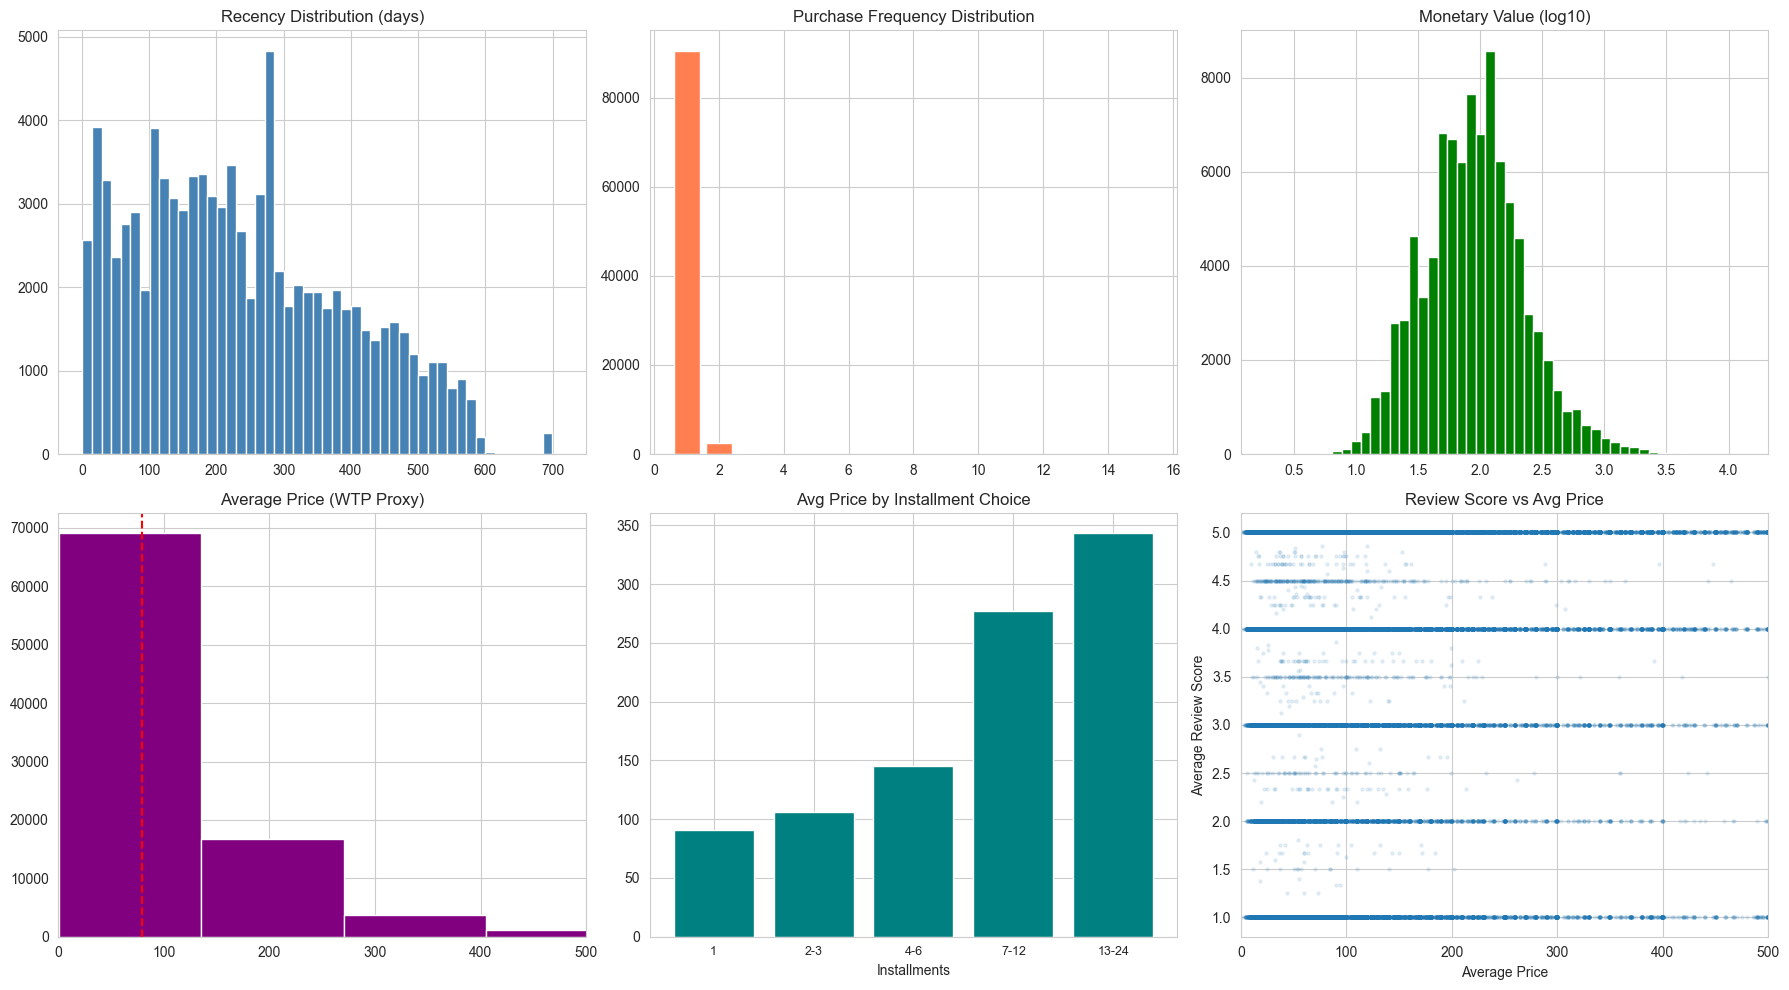

In [11]:
# RFM Analysis
reference_date = delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = delivered.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum'),
    avg_price=('price', 'mean'),
    max_price=('price', 'max'),
    avg_installments=('num_installments', 'mean'),
    avg_review=('review_score', 'mean'),
    num_categories=('product_category_name_english', 'nunique')
).reset_index()

print("RFM Summary:")
print(rfm[['recency', 'frequency', 'monetary', 'avg_price']].describe())

# Repeat purchase rate
repeat_customers = rfm[rfm['frequency'] > 1]
print(f"\nRepeat purchase rate: {len(repeat_customers)/len(rfm)*100:.1f}%")
print(f"Total customers: {len(rfm):,}")
print(f"Repeat customers: {len(repeat_customers):,}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Recency distribution
axes[0, 0].hist(rfm['recency'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Recency Distribution (days)')

# Frequency distribution
freq_counts = rfm['frequency'].value_counts().sort_index().head(10)
axes[0, 1].bar(freq_counts.index, freq_counts.values, color='coral')
axes[0, 1].set_title('Purchase Frequency Distribution')

# Monetary distribution (log scale)
axes[0, 2].hist(np.log10(rfm['monetary'] + 1), bins=50, color='green', edgecolor='white')
axes[0, 2].set_title('Monetary Value (log10)')

# Average price as WTP proxy
axes[1, 0].hist(rfm['avg_price'], bins=50, color='purple', edgecolor='white')
axes[1, 0].axvline(rfm['avg_price'].median(), color='red', linestyle='--')
axes[1, 0].set_title('Average Price (WTP Proxy)')
axes[1, 0].set_xlim(0, 500)

# Installments as budget signal
inst_wtp = rfm.groupby(pd.cut(rfm['avg_installments'], bins=[0,1,3,6,12,24]))['avg_price'].mean()
axes[1, 1].bar(range(len(inst_wtp)), inst_wtp.values, color='teal')
axes[1, 1].set_xticks(range(len(inst_wtp)))
axes[1, 1].set_xticklabels(['1', '2-3', '4-6', '7-12', '13-24'], fontsize=9)
axes[1, 1].set_title('Avg Price by Installment Choice')
axes[1, 1].set_xlabel('Installments')

# Review score vs price
axes[1, 2].scatter(rfm['avg_price'], rfm['avg_review'], alpha=0.1, s=5)
axes[1, 2].set_title('Review Score vs Avg Price')
axes[1, 2].set_xlabel('Average Price')
axes[1, 2].set_ylabel('Average Review Score')
axes[1, 2].set_xlim(0, 500)

plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_customer_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Product Segmentation

Cluster products into manageable segments for the simulator using price level, order frequency, category, and review scores.

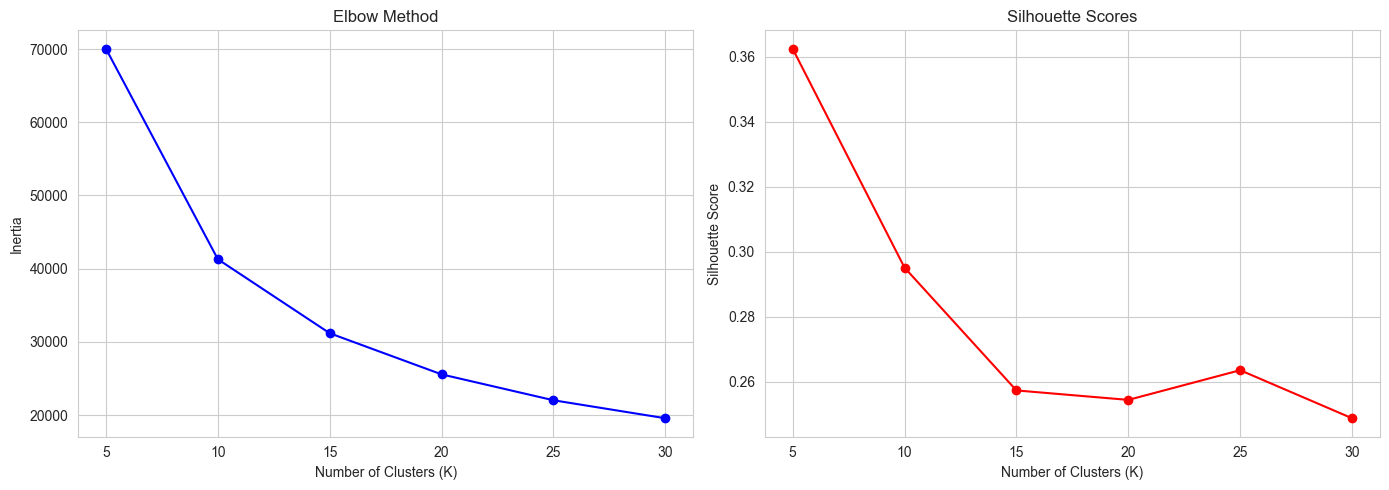


Product Segment Profiles (K=15):
         num_products    avg_price  avg_orders  total_revenue  avg_review     top_category
segment                                                                                   
10               1040    96.947043   32.551923     3185672.80    4.043892   bed_bath_table
7                2582   152.676002    5.106119     2144369.08    4.248373   sports_leisure
13               1658   638.185503    1.490953     1606800.22    4.530910    watches_gifts
5                1002   145.230428    8.506986     1066509.91    4.133593    health_beauty
2                4876   165.746664    1.202420      971146.87    4.809731   sports_leisure
4                1433   276.433975    1.592463      654503.20    4.493993  furniture_decor
8                 504   723.944627    1.827381      634963.47    3.940321             auto
3                 181   145.864349   25.867403      625021.70    4.147423    watches_gifts
0                2554    36.045738    6.021143      5558

In [12]:
# Product-level features for segmentation
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

product_features = delivered.groupby('product_id').agg(
    avg_price=('price', 'mean'),
    price_std=('price', 'std'),
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_freight=('freight_value', 'mean'),
    avg_review=('review_score', 'mean'),
    category=('product_category_name_english', 'first'),
    num_sellers=('seller_id', 'nunique'),
    avg_weight=('product_weight_g', 'mean')
).reset_index()

product_features = product_features.fillna(0)
product_features['price_std'] = product_features['price_std'].fillna(0)
product_features['log_price'] = np.log1p(product_features['avg_price'])
product_features['log_orders'] = np.log1p(product_features['total_orders'])

# Clustering features
cluster_features = ['log_price', 'log_orders', 'avg_freight', 'avg_review', 'num_sellers']
X = product_features[cluster_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal K using elbow and silhouette
K_range = range(5, 31, 5)
inertias = []
silhouettes = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores')

plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_clustering_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Use K=15 as a good balance
K_OPTIMAL = 15
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
product_features['segment'] = km_final.fit_predict(X_scaled)

# Segment profiles
seg_profile = product_features.groupby('segment').agg(
    num_products=('product_id', 'count'),
    avg_price=('avg_price', 'mean'),
    avg_orders=('total_orders', 'mean'),
    total_revenue=('total_revenue', 'sum'),
    avg_review=('avg_review', 'mean'),
    top_category=('category', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown')
).sort_values('total_revenue', ascending=False)

print(f"\nProduct Segment Profiles (K={K_OPTIMAL}):")
print(seg_profile.to_string())

# Save segment mapping
product_segment_map = product_features[['product_id', 'segment', 'avg_price', 'total_orders', 'category']].copy()
product_segment_map.to_csv(DATA_DIR + 'product_segments.csv', index=False)
print(f"\nSaved product segment mapping ({len(product_segment_map):,} products -> {K_OPTIMAL} segments)")

In [13]:
# Segment-level elasticity estimation
# Map segments back to transaction data
delivered_seg = delivered.merge(product_features[['product_id', 'segment']], on='product_id', how='left')

# Compute weekly demand-price pairs per segment
delivered_seg['week_num'] = delivered_seg['order_purchase_timestamp'].dt.isocalendar().week.astype(int)
delivered_seg['year'] = delivered_seg['order_purchase_timestamp'].dt.year

seg_weekly = delivered_seg.groupby(['segment', 'year', 'week_num']).agg(
    avg_price=('price', 'mean'),
    quantity=('order_id', 'count'),
    revenue=('price', 'sum')
).reset_index()

# Estimate log-log elasticity per segment
segment_elasticities = {}
for seg in range(K_OPTIMAL):
    seg_data = seg_weekly[seg_weekly['segment'] == seg]
    if len(seg_data) > 10 and seg_data['quantity'].min() > 0:
        log_p = np.log(seg_data['avg_price'])
        log_q = np.log(seg_data['quantity'])
        slope, intercept, r_value, p_value, std_err = stats.linregress(log_p, log_q)
        segment_elasticities[seg] = {
            'elasticity': slope,
            'intercept': intercept,
            'r2': r_value**2,
            'p_value': p_value,
            'std_err': std_err,
            'n_obs': len(seg_data),
            'base_price': seg_data['avg_price'].median(),
            'base_demand': seg_data['quantity'].median()
        }

elast_df = pd.DataFrame(segment_elasticities).T
elast_df.index.name = 'segment'

# For segments with unreliable elasticity (positive or extreme), use economic priors
for seg in range(K_OPTIMAL):
    if seg not in segment_elasticities or segment_elasticities[seg]['elasticity'] > 0:
        # Assign default elasticity based on price level
        base_price = seg_profile.loc[seg, 'avg_price'] if seg in seg_profile.index else 100
        if base_price < 50:
            default_elast = -0.8  # Low price = less elastic
        elif base_price < 150:
            default_elast = -1.2
        else:
            default_elast = -1.8  # High price = more elastic
        
        seg_data = seg_weekly[seg_weekly['segment'] == seg]
        segment_elasticities[seg] = {
            'elasticity': default_elast,
            'intercept': np.log(seg_data['quantity'].median()) if len(seg_data) > 0 else 4.0,
            'r2': 0.0,  # Prior, not estimated
            'p_value': 1.0,
            'std_err': 0.5,
            'n_obs': len(seg_data),
            'base_price': seg_data['avg_price'].median() if len(seg_data) > 0 else base_price,
            'base_demand': seg_data['quantity'].median() if len(seg_data) > 0 else 50
        }

elast_df = pd.DataFrame(segment_elasticities).T
elast_df.index.name = 'segment'
print("Segment-Level Elasticity Parameters:")
print(elast_df[['elasticity', 'base_price', 'base_demand', 'r2', 'n_obs']].to_string())

# Save calibration parameters
elast_df.to_csv(DATA_DIR + 'segment_elasticities.csv')
print(f"\nSaved to segment_elasticities.csv")

# Also compute temporal arrival rates (weekly)
weekly_arrivals = delivered_seg.groupby(['year', 'week_num']).size()
print(f"\nWeekly arrival rate: mean={weekly_arrivals.mean():.0f}, std={weekly_arrivals.std():.0f}")
print(f"Fitted Poisson lambda (per week): {weekly_arrivals.mean():.0f}")

Segment-Level Elasticity Parameters:
         elasticity  base_price  base_demand        r2  n_obs
segment                                                      
0         -0.800000   36.053792        160.5  0.000000   90.0
1         -1.200000   79.239623         62.0  0.000000   89.0
2         -3.800718  166.682292         63.0  0.090936   89.0
3         -1.273393  141.426667         40.0  0.081198   85.0
4         -1.800000  288.054688         21.0  0.000000   87.0
5         -0.523082  124.470071         78.0  0.017187   89.0
6         -0.800000   43.827462         24.0  0.000000   90.0
7         -1.800000  158.588352        138.0  0.000000   89.0
8         -1.800000  642.114048         10.0  0.000000   84.0
9         -0.014020  899.000000          1.0  0.000292   55.0
10        -1.200000   92.094494        380.0  0.000000   89.0
11        -0.043050  257.124830         18.0  0.000491   86.0
12        -1.142197   58.947890         73.5  0.007593   88.0
13        -1.800000  634.736299  